In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

In [3]:
transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_4_tpm_normalized.csv",
    index_col=0,
)
rows_to_drop_expression_data = [
    "A2450525897_n01_undetermined",
    "A2449446903_n01_undetermined",
    "B250508004_n01_undetermined",
    "B2449500127_n01_undetermined",
]
transcriptome = transcriptome.drop(index=rows_to_drop_expression_data)
transcriptome = transcriptome.sort_index()


metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_4_metadata_merged_luke.csv",
    index_col=0,
)
metadata = metadata.drop(
    columns=[
        "arb.sort",
        "sample-id",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
        "Multimapping",
        "Unmapped Over Mapped",
    ]
)
metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
luke_time_data_format = "%-m/%-d/%y %-H:%-M"
metadata["Date and Time"] = pd.to_datetime(
    metadata["Date and Time"], format=luke_time_data_format
)


unusable_samples = [
    "A2450525897_n01_LICRNA01_A06",
    "A2450525897_n01_LICRNA01_A08",
    "A2450525897_n01_LICRNA01_C11",
    "A2450525897_n01_LICRNA01_D11",
    "A2450525897_n01_LICRNA01_D12",
    "A2449446903_n01_LICRNA02_F01",
    "B2449500127_n01_LICRNA04_A04",
    "B2449500127_n01_LICRNA04_A06",
    "B2449500127_n01_LICRNA04_A07",
]
borderline_unusable = [
    "A2450525897_n01_LICRNA01_F03",
    "A2450525897_n01_LICRNA01_G07",
    "A2449446903_n01_LICRNA02_A04",
    "A2449446903_n01_LICRNA02_H10",
    "B2449500127_n01_LICRNA04_H02",
    "B2449500127_n01_LICRNA04_H11",
]
all_unsable = borderline_unusable + unusable_samples

trimmed_transcriptome = transcriptome.drop(index=all_unsable)
trimmed_metadata = metadata.drop(index=all_unsable)
long_term_transcriptome = trimmed_transcriptome.loc[
    trimmed_metadata["Experiment Type"] == "Long Term"
]
long_term_metadata = trimmed_metadata.loc[
    trimmed_metadata["Experiment Type"] == "Long Term"
]


microbiome_abundance = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Microbiome/lic2024_16S_rab.csv"
)
long_term_microbiome = microbiome_abundance.merge(
    metadata[["sampID", "Experiment Type"]], left_on="plantID", right_on="sampID"
)
long_term_microbiome = long_term_microbiome.loc[
    long_term_microbiome["Experiment Type"] == "Long Term"
]
long_term_microbiome

total_load_df = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Microbiome/lic2024_ham_16S_ITS.csv",
    index_col=0,
)

long_term_metadata_w_load_info = long_term_metadata.merge(
    total_load_df[["ham16s", "giitsreads", "hamits"]],
    left_on="sampID",
    right_index=True,
    how="left",
)
defense_gene_list = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/load_correlated_defense_genes_union_GO_and_FLG.csv"
)

In [4]:
defense_gene_list

,gene
0,AT1G01100
1,AT1G01230
2,AT1G04510
3,AT1G07360
4,AT1G08450
...,...
194,AT5G64810
195,AT5G65200
196,AT5G67300
197,AT5G67330


In [5]:
long_term_transcriptome

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
A2449446903_n01_LICRNA02_A01,0.382839,11.929183,0.0,3.731527,3.602189,0.0,0.0,31.063543,0.0,3.966935,...,17.950907,44.209074,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,6.266498
A2449446903_n01_LICRNA02_A02,0.000000,5.826682,0.0,1.501594,3.439569,0.0,0.0,22.712417,0.0,18.186693,...,1.986484,9.688606,0.000000,5.501032,0.0,0.0,0.519342,0.0,0.000000,3.467317
A2449446903_n01_LICRNA02_A03,1.021565,7.683520,0.0,0.301733,2.700528,0.0,0.0,42.431625,0.0,12.937632,...,7.983340,16.384320,0.000000,7.983340,0.0,0.0,0.166972,0.0,0.000000,0.000000
A2449446903_n01_LICRNA02_A05,0.732717,3.149144,0.0,1.947758,3.742586,0.0,0.0,26.541337,0.0,23.861601,...,17.178143,17.005325,0.000000,0.000000,0.0,0.0,0.628742,0.0,0.000000,0.000000
A2449446903_n01_LICRNA02_A06,1.614233,1.238895,0.0,6.130092,4.215597,0.0,0.0,19.379509,0.0,5.006570,...,16.219201,43.599301,0.000000,0.000000,0.0,0.0,1.074213,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_G04,0.496406,8.356214,0.0,3.372257,3.069350,0.0,0.0,60.177712,0.0,23.758980,...,3.879318,10.115887,0.000000,10.145909,0.0,0.0,0.365112,0.0,0.000000,4.401263
B250508004_n01_LICRNA03_H01,1.365172,7.171230,0.0,1.926502,3.574878,0.0,0.0,53.113875,0.0,40.291678,...,1.185396,6.525640,16.595542,4.923952,0.0,0.0,0.384285,0.0,0.000000,4.448467
B250508004_n01_LICRNA03_H02,3.903593,1.198375,0.0,1.482399,3.897820,0.0,0.0,24.240094,0.0,8.805132,...,91.517576,14.520754,0.000000,2.011375,0.0,0.0,0.000000,0.0,46.732379,2.281997
B250508004_n01_LICRNA03_H03,0.365827,4.913399,0.0,0.972466,3.761743,0.0,0.0,14.311528,0.0,10.334051,...,4.288305,7.558461,0.000000,0.329870,0.0,0.0,0.022423,0.0,0.000000,4.865277


In [6]:
transcriptome_in_defense_gene_list = long_term_transcriptome.loc[
    :, long_term_transcriptome.columns.isin(defense_gene_list["gene"])
]
summed_zscored_transcriptome = (
    transcriptome_in_defense_gene_list.apply(zscore).sum(axis=1) / 199
)
long_term_metadata_w_load_info = long_term_metadata_w_load_info.merge(
    summed_zscored_transcriptome.rename("Summed Defense Z Score"),
    left_index=True,
    right_index=True,
)

In [7]:
long_term_metadata_w_load_info

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,...,plate_col,Total Reads,Experiment Type,Sample Month,daysincestart,Date and Time,ham16s,giitsreads,hamits,Summed Defense Z Score
A2450525897_n01_LICRNA01_A01,A01,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2633048.0,112554.0,...,1,2248661.0,Long Term,November,0,2023-11-01 08:00:00,0.242587,50737,2.494058,1.326926
A2450525897_n01_LICRNA01_B01,B01,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5074184.0,226718.0,...,1,5984566.0,Long Term,November,0,2023-11-01 08:00:00,0.367494,45421,3.072081,0.799594
A2450525897_n01_LICRNA01_C01,C01,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2283008.0,97848.0,...,1,2936453.0,Long Term,November,0,2023-11-01 08:00:00,0.507472,39166,1.665143,2.305566
A2450525897_n01_LICRNA01_D01,D01,LIC004,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,1263467.0,49095.0,...,1,1359823.0,Long Term,November,0,2023-11-01 08:00:00,0.554697,45367,2.968876,2.048900
A2450525897_n01_LICRNA01_E01,E01,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,3004324.0,135512.0,...,1,2680737.0,Long Term,November,0,2023-11-01 08:00:00,0.594141,46725,2.386431,0.560580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_D04,D04,LIC364,plant,t08,12/5/23,8:00,LIC_04,LICRNA_03,3938079.0,607579.0,...,4,7492987.0,Long Term,December,34,2023-12-05 08:00:00,0.082159,54349,1.870246,-0.681656
B250508004_n01_LICRNA03_E04,E04,LIC365,plant,t08,12/5/23,8:00,LIC_04,LICRNA_03,2930881.0,411155.0,...,4,5576195.0,Long Term,December,34,2023-12-05 08:00:00,0.108041,52430,1.000706,-0.471329
B250508004_n01_LICRNA03_F04,F04,LIC366,plant,t08,12/5/23,8:00,LIC_04,LICRNA_03,3451594.0,558062.0,...,4,7678391.0,Long Term,December,34,2023-12-05 08:00:00,0.103646,52968,2.009666,-0.704001
B250508004_n01_LICRNA03_G04,G04,LIC367,plant,t08,12/5/23,8:00,LIC_04,LICRNA_03,1477644.0,189073.0,...,4,2732871.0,Long Term,December,34,2023-12-05 08:00:00,0.038971,51944,0.693343,-0.232981


In [8]:
genus_sum = (
    long_term_microbiome[["Sample", "Genus", "AbundR100"]]
    .groupby(["Sample", "Genus"])
    .sum()
)
genus_sum = genus_sum.reset_index()

genus_sum_w_tp = genus_sum.merge(
    metadata[["sampID", "timepoint"]], left_on="Sample", right_on="sampID"
)


all_present_genus = genus_sum_w_tp["Genus"].unique()

for sampID in genus_sum_w_tp["sampID"].unique():
    sampid_only_df = genus_sum_w_tp.loc[genus_sum_w_tp["sampID"] == sampID]
    present_genus_in_samp = sampid_only_df["Genus"].unique()
    difference_in_present_bacteria = list(
        set(all_present_genus) - set(present_genus_in_samp)
    )
    current_time_point = sampid_only_df["timepoint"].iloc[0]
    empty_df_to_add = pd.DataFrame(
        columns=["Sample", "Genus", "AbundR100", "sampID", "timepoint"]
    )
    empty_df_to_add["Genus"] = difference_in_present_bacteria
    empty_df_to_add["Sample"] = sampID
    empty_df_to_add["AbundR100"] = 0
    empty_df_to_add["sampID"] = sampID
    empty_df_to_add["timepoint"] = current_time_point
    genus_sum_w_tp = pd.concat([genus_sum_w_tp, empty_df_to_add])

In [9]:
long_term_transcriptome

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
A2449446903_n01_LICRNA02_A01,0.382839,11.929183,0.0,3.731527,3.602189,0.0,0.0,31.063543,0.0,3.966935,...,17.950907,44.209074,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,6.266498
A2449446903_n01_LICRNA02_A02,0.000000,5.826682,0.0,1.501594,3.439569,0.0,0.0,22.712417,0.0,18.186693,...,1.986484,9.688606,0.000000,5.501032,0.0,0.0,0.519342,0.0,0.000000,3.467317
A2449446903_n01_LICRNA02_A03,1.021565,7.683520,0.0,0.301733,2.700528,0.0,0.0,42.431625,0.0,12.937632,...,7.983340,16.384320,0.000000,7.983340,0.0,0.0,0.166972,0.0,0.000000,0.000000
A2449446903_n01_LICRNA02_A05,0.732717,3.149144,0.0,1.947758,3.742586,0.0,0.0,26.541337,0.0,23.861601,...,17.178143,17.005325,0.000000,0.000000,0.0,0.0,0.628742,0.0,0.000000,0.000000
A2449446903_n01_LICRNA02_A06,1.614233,1.238895,0.0,6.130092,4.215597,0.0,0.0,19.379509,0.0,5.006570,...,16.219201,43.599301,0.000000,0.000000,0.0,0.0,1.074213,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_G04,0.496406,8.356214,0.0,3.372257,3.069350,0.0,0.0,60.177712,0.0,23.758980,...,3.879318,10.115887,0.000000,10.145909,0.0,0.0,0.365112,0.0,0.000000,4.401263
B250508004_n01_LICRNA03_H01,1.365172,7.171230,0.0,1.926502,3.574878,0.0,0.0,53.113875,0.0,40.291678,...,1.185396,6.525640,16.595542,4.923952,0.0,0.0,0.384285,0.0,0.000000,4.448467
B250508004_n01_LICRNA03_H02,3.903593,1.198375,0.0,1.482399,3.897820,0.0,0.0,24.240094,0.0,8.805132,...,91.517576,14.520754,0.000000,2.011375,0.0,0.0,0.000000,0.0,46.732379,2.281997
B250508004_n01_LICRNA03_H03,0.365827,4.913399,0.0,0.972466,3.761743,0.0,0.0,14.311528,0.0,10.334051,...,4.288305,7.558461,0.000000,0.329870,0.0,0.0,0.022423,0.0,0.000000,4.865277


In [10]:
long_term_metadata_w_load_info

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,...,plate_col,Total Reads,Experiment Type,Sample Month,daysincestart,Date and Time,ham16s,giitsreads,hamits,Summed Defense Z Score
A2450525897_n01_LICRNA01_A01,A01,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2633048.0,112554.0,...,1,2248661.0,Long Term,November,0,2023-11-01 08:00:00,0.242587,50737,2.494058,1.326926
A2450525897_n01_LICRNA01_B01,B01,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5074184.0,226718.0,...,1,5984566.0,Long Term,November,0,2023-11-01 08:00:00,0.367494,45421,3.072081,0.799594
A2450525897_n01_LICRNA01_C01,C01,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2283008.0,97848.0,...,1,2936453.0,Long Term,November,0,2023-11-01 08:00:00,0.507472,39166,1.665143,2.305566
A2450525897_n01_LICRNA01_D01,D01,LIC004,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,1263467.0,49095.0,...,1,1359823.0,Long Term,November,0,2023-11-01 08:00:00,0.554697,45367,2.968876,2.048900
A2450525897_n01_LICRNA01_E01,E01,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,3004324.0,135512.0,...,1,2680737.0,Long Term,November,0,2023-11-01 08:00:00,0.594141,46725,2.386431,0.560580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_D04,D04,LIC364,plant,t08,12/5/23,8:00,LIC_04,LICRNA_03,3938079.0,607579.0,...,4,7492987.0,Long Term,December,34,2023-12-05 08:00:00,0.082159,54349,1.870246,-0.681656
B250508004_n01_LICRNA03_E04,E04,LIC365,plant,t08,12/5/23,8:00,LIC_04,LICRNA_03,2930881.0,411155.0,...,4,5576195.0,Long Term,December,34,2023-12-05 08:00:00,0.108041,52430,1.000706,-0.471329
B250508004_n01_LICRNA03_F04,F04,LIC366,plant,t08,12/5/23,8:00,LIC_04,LICRNA_03,3451594.0,558062.0,...,4,7678391.0,Long Term,December,34,2023-12-05 08:00:00,0.103646,52968,2.009666,-0.704001
B250508004_n01_LICRNA03_G04,G04,LIC367,plant,t08,12/5/23,8:00,LIC_04,LICRNA_03,1477644.0,189073.0,...,4,2732871.0,Long Term,December,34,2023-12-05 08:00:00,0.038971,51944,0.693343,-0.232981


In [11]:
genus_sum_w_tp

,Sample,Genus,AbundR100,sampID,timepoint
0,LIC001,Actinomycetospora,0.6,LIC001,t01
1,LIC001,Actinoplanes,1.1,LIC001,t01
2,LIC001,Aeromicrobium,0.8,LIC001,t01
3,LIC001,Blastococcus,1.7,LIC001,t01
4,LIC001,Caulobacter_487784,0.5,LIC001,t01
...,...,...,...,...,...
109,LIC368,Aquabacterium_A_591266,0.0,LIC368,t08
110,LIC368,Massilia_573446,0.0,LIC368,t08
111,LIC368,Microlunatus_B,0.0,LIC368,t08
112,LIC368,Labilithrix,0.0,LIC368,t08


In [12]:
plotting_df = long_term_metadata_w_load_info[
    [
        "sampID",
        "timepoint",
        "ham16s",
        "Summed Defense Z Score",
        "Experiment Type",
    ]
]
plotting_df

,sampID,timepoint,ham16s,Summed Defense Z Score,Experiment Type
A2450525897_n01_LICRNA01_A01,LIC001,t01,0.242587,1.326926,Long Term
A2450525897_n01_LICRNA01_B01,LIC002,t01,0.367494,0.799594,Long Term
A2450525897_n01_LICRNA01_C01,LIC003,t01,0.507472,2.305566,Long Term
A2450525897_n01_LICRNA01_D01,LIC004,t01,0.554697,2.048900,Long Term
A2450525897_n01_LICRNA01_E01,LIC005,t01,0.594141,0.560580,Long Term
...,...,...,...,...,...
B250508004_n01_LICRNA03_D04,LIC364,t08,0.082159,-0.681656,Long Term
B250508004_n01_LICRNA03_E04,LIC365,t08,0.108041,-0.471329,Long Term
B250508004_n01_LICRNA03_F04,LIC366,t08,0.103646,-0.704001,Long Term
B250508004_n01_LICRNA03_G04,LIC367,t08,0.038971,-0.232981,Long Term


In [13]:
all_present_genus
for genus in all_present_genus:
    matched_genus_df = genus_sum_w_tp.loc[genus_sum_w_tp["Genus"] == genus]
    plotting_df = plotting_df.merge(
        matched_genus_df[["Sample", "AbundR100"]],
        left_on="sampID",
        right_on="Sample",
    )
    plotting_df = plotting_df.rename(columns={"AbundR100": f"{genus}_AbundR100"})
    plotting_df = plotting_df.drop(columns=["Sample"])


matched_genus_df

,Sample,Genus,AbundR100,sampID,timepoint
5088,LIC368,Herbiconiux_382278,0.5,LIC368,t08
47,LIC001,Herbiconiux_382278,0.0,LIC001,t01
47,LIC002,Herbiconiux_382278,0.0,LIC002,t01
47,LIC003,Herbiconiux_382278,0.0,LIC003,t01
55,LIC004,Herbiconiux_382278,0.0,LIC004,t01
...,...,...,...,...,...
58,LIC363,Herbiconiux_382278,0.0,LIC363,t08
50,LIC364,Herbiconiux_382278,0.0,LIC364,t08
57,LIC365,Herbiconiux_382278,0.0,LIC365,t08
57,LIC366,Herbiconiux_382278,0.0,LIC366,t08


In [14]:
plotting_df

,sampID,timepoint,ham16s,Summed Defense Z Score,Experiment Type,Actinomycetospora_AbundR100,Actinoplanes_AbundR100,Aeromicrobium_AbundR100,Blastococcus_AbundR100,Caulobacter_487784_AbundR100,...,Massilia_573446_AbundR100,Mesorhizobium_I_AbundR100,Umezawaea_AbundR100,Croceibacterium_484881_AbundR100,Rhizorhabdus_AbundR100,Polaromonas_AbundR100,Jatrophihabitans_A_372606_AbundR100,UBA4416_AbundR100,Allorhizobium_500053_AbundR100,Herbiconiux_382278_AbundR100
0,LIC001,t01,0.242587,1.326926,Long Term,0.6,1.1,0.8,1.7,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,LIC002,t01,0.367494,0.799594,Long Term,0.0,0.0,0.0,3.1,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,LIC003,t01,0.507472,2.305566,Long Term,0.0,0.0,4.9,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,LIC004,t01,0.554697,2.048900,Long Term,1.8,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,LIC005,t01,0.594141,0.560580,Long Term,0.6,0.0,0.6,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,LIC364,t08,0.082159,-0.681656,Long Term,0.5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
210,LIC365,t08,0.108041,-0.471329,Long Term,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
211,LIC366,t08,0.103646,-0.704001,Long Term,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
212,LIC367,t08,0.038971,-0.232981,Long Term,3.4,0.5,0.5,1.1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.5,0.0


In [15]:
plotting_df["Rank Within Timepoint"] = plotting_df.groupby("timepoint").rank()["ham16s"]
plotting_df

,sampID,timepoint,ham16s,Summed Defense Z Score,Experiment Type,Actinomycetospora_AbundR100,Actinoplanes_AbundR100,Aeromicrobium_AbundR100,Blastococcus_AbundR100,Caulobacter_487784_AbundR100,...,Mesorhizobium_I_AbundR100,Umezawaea_AbundR100,Croceibacterium_484881_AbundR100,Rhizorhabdus_AbundR100,Polaromonas_AbundR100,Jatrophihabitans_A_372606_AbundR100,UBA4416_AbundR100,Allorhizobium_500053_AbundR100,Herbiconiux_382278_AbundR100,Rank Within Timepoint
0,LIC001,t01,0.242587,1.326926,Long Term,0.6,1.1,0.8,1.7,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,LIC002,t01,0.367494,0.799594,Long Term,0.0,0.0,0.0,3.1,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
2,LIC003,t01,0.507472,2.305566,Long Term,0.0,0.0,4.9,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
3,LIC004,t01,0.554697,2.048900,Long Term,1.8,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
4,LIC005,t01,0.594141,0.560580,Long Term,0.6,0.0,0.6,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,LIC364,t08,0.082159,-0.681656,Long Term,0.5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
210,LIC365,t08,0.108041,-0.471329,Long Term,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
211,LIC366,t08,0.103646,-0.704001,Long Term,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
212,LIC367,t08,0.038971,-0.232981,Long Term,3.4,0.5,0.5,1.1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.5,0.0,1.0


In [16]:
plotting_df["timepoint"].unique()

array(['t01', 't02', 't03', 't04', 't05', 't06', 't07', 't09', 't10',
       't11', 't12', 't13', 't14', 't15', 't17', 't18', 't19', 't20',
       't21', 't22', 't23', 't25', 't26', 't27', 't28', 't24', 't16',
       't08'], dtype=object)

In [17]:
plotting_df["Zscore within Timepoint"] = plotting_df.groupby("timepoint")[
    "ham16s"
].transform(lambda x: zscore(x))

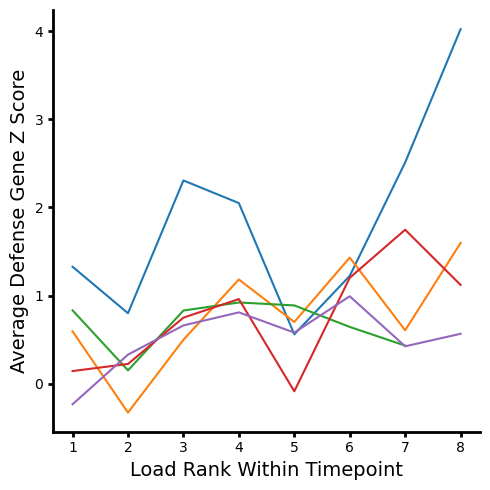

In [18]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.lineplot(
    data=plotting_df[
        plotting_df["timepoint"].isin(["t01", "t02", "t03", "t04", "t05"])
    ],
    x="Rank Within Timepoint",
    y="Summed Defense Z Score",
    hue="timepoint",
)
plt.xlabel("Load Rank Within Timepoint", fontsize=14)
plt.ylabel("Average Defense Gene Z Score", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
ax.get_legend().remove()
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
# plt.ylim(-.02,1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

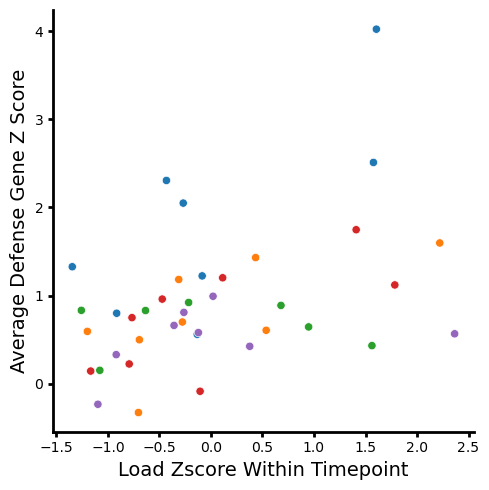

In [19]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    data=plotting_df[
        plotting_df["timepoint"].isin(["t01", "t02", "t03", "t04", "t05"])
    ],
    x="Zscore within Timepoint",
    y="Summed Defense Z Score",
    hue="timepoint",
)
plt.xlabel("Load Zscore Within Timepoint", fontsize=14)
plt.ylabel("Average Defense Gene Z Score", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
ax.get_legend().remove()
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
# plt.ylim(-.02,1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

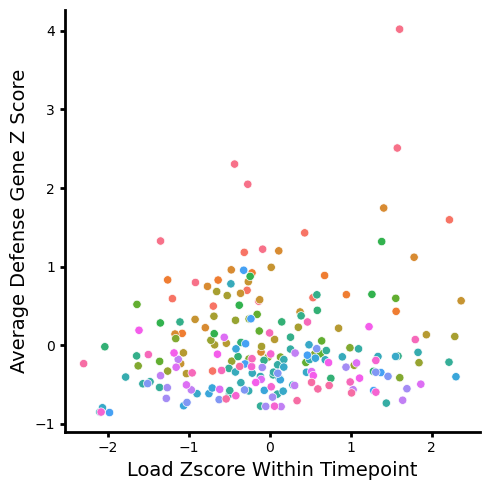

In [20]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    data=plotting_df[plotting_df["Experiment Type"] == "Long Term"],
    x="Zscore within Timepoint",
    y="Summed Defense Z Score",
    hue="timepoint",
)
plt.xlabel("Load Zscore Within Timepoint", fontsize=14)
plt.ylabel("Average Defense Gene Z Score", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
ax.get_legend().remove()
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
# plt.ylim(-.02,1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

In [21]:
plotting_df

,sampID,timepoint,ham16s,Summed Defense Z Score,Experiment Type,Actinomycetospora_AbundR100,Actinoplanes_AbundR100,Aeromicrobium_AbundR100,Blastococcus_AbundR100,Caulobacter_487784_AbundR100,...,Umezawaea_AbundR100,Croceibacterium_484881_AbundR100,Rhizorhabdus_AbundR100,Polaromonas_AbundR100,Jatrophihabitans_A_372606_AbundR100,UBA4416_AbundR100,Allorhizobium_500053_AbundR100,Herbiconiux_382278_AbundR100,Rank Within Timepoint,Zscore within Timepoint
0,LIC001,t01,0.242587,1.326926,Long Term,0.6,1.1,0.8,1.7,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.346435
1,LIC002,t01,0.367494,0.799594,Long Term,0.0,0.0,0.0,3.1,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,-0.915409
2,LIC003,t01,0.507472,2.305566,Long Term,0.0,0.0,4.9,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,-0.432376
3,LIC004,t01,0.554697,2.048900,Long Term,1.8,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,-0.269414
4,LIC005,t01,0.594141,0.560580,Long Term,0.6,0.0,0.6,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,-0.133303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,LIC364,t08,0.082159,-0.681656,Long Term,0.5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,-0.536273
210,LIC365,t08,0.108041,-0.471329,Long Term,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.518322
211,LIC366,t08,0.103646,-0.704001,Long Term,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.339212
212,LIC367,t08,0.038971,-0.232981,Long Term,3.4,0.5,0.5,1.1,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,0.5,0.0,1.0,-2.296023


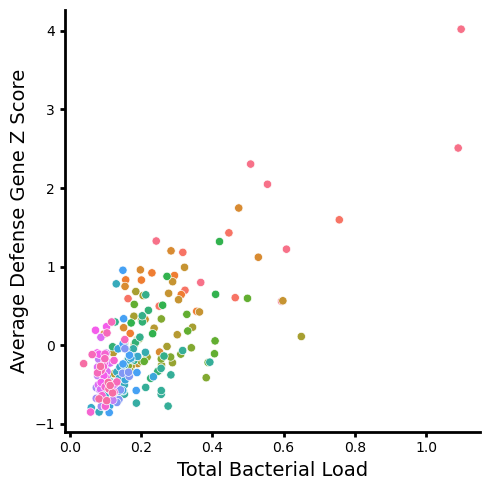

In [22]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    data=plotting_df[plotting_df["Experiment Type"] == "Long Term"],
    x="ham16s",
    y="Summed Defense Z Score",
    hue="timepoint",
)
plt.xlabel("Total Bacterial Load", fontsize=14)
plt.ylabel("Average Defense Gene Z Score", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
ax.get_legend().remove()
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

In [23]:
abund_cols = [col for col in plotting_df.columns if col.endswith("_AbundR100")]
correlation_df = pd.DataFrame(
    {
        "Column": abund_cols,
        "Correlation_with_Summed_Defense_Z_Score": [
            plotting_df["Summed Defense Z Score"].corr(plotting_df[col])
            for col in abund_cols
        ],
    }
).sort_values("Correlation_with_Summed_Defense_Z_Score", ascending=False)

correlation_df

/Users/michael/miniconda3/envs/Luke_terrace/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/michael/miniconda3/envs/Luke_terrace/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,Column,Correlation_with_Summed_Defense_Z_Score
63,Alsobacter_AbundR100,0.421464
6,Curtobacterium_AbundR100,0.379709
21,Microbacterium_A_383321_AbundR100,0.300380
26,Pseudomonas_B_650453_AbundR100,0.299779
46,Rhizobium_C_501058_AbundR100,0.295323
...,...,...
33,Variovorax_AbundR100,-0.167741
29,Rhodoferax_C_AbundR100,-0.188509
8,Flavobacterium_AbundR100,-0.208944
17,Kordiimonas_AbundR100,-0.455551


In [24]:
correlation_df.head(20)

,Column,Correlation_with_Summed_Defense_Z_Score
63,Alsobacter_AbundR100,0.421464
6,Curtobacterium_AbundR100,0.379709
21,Microbacterium_A_383321_AbundR100,0.300380
26,Pseudomonas_B_650453_AbundR100,0.299779
46,Rhizobium_C_501058_AbundR100,0.295323
23,Neorhizobium_500197_AbundR100,0.249880
9,Friedmanniella_AbundR100,0.242837
60,Buchnera_AbundR100,0.219857
2,Aeromicrobium_AbundR100,0.211997
4,Caulobacter_487784_AbundR100,0.196244


Top 3 taxa: ['Curtobacterium', 'Microbacterium_A_383321', 'Pseudomonas_B_650453']
Bottom 3 taxa: ['Rhodoferax_C', 'Flavobacterium', 'Kordiimonas']


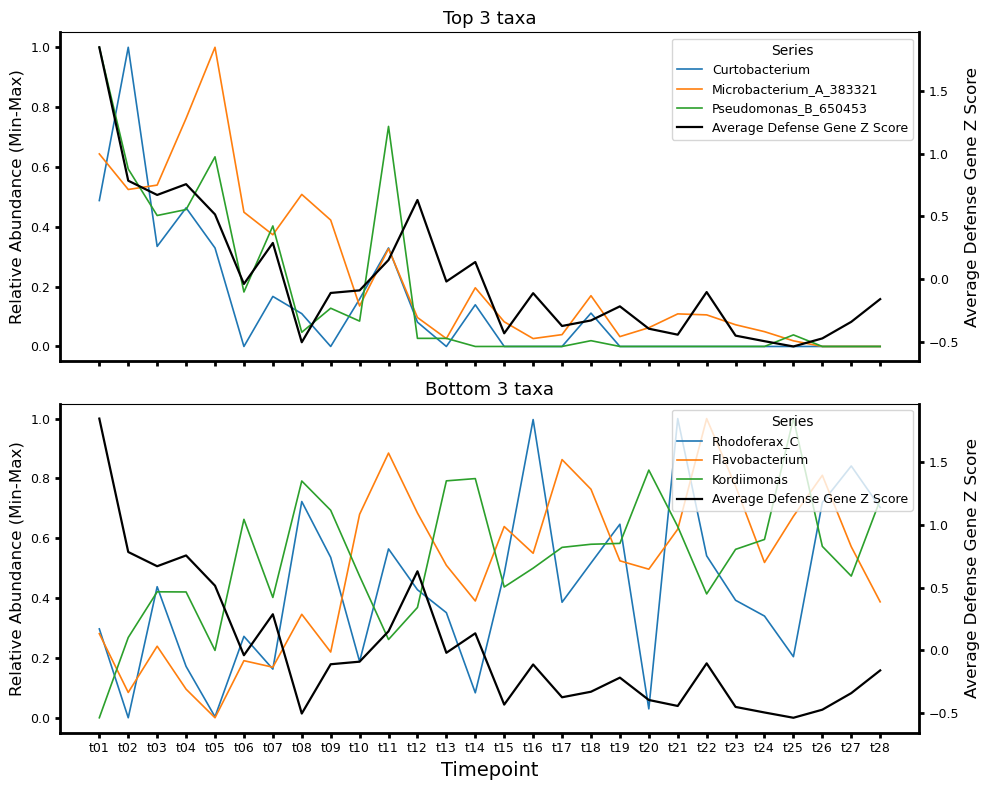

In [25]:
from matplotlib.lines import Line2D

# Build correlation_df if it is not already available
if "correlation_df" not in globals():
    abund_cols = [col for col in plotting_df.columns if col.endswith("_AbundR100")]
    correlation_df = pd.DataFrame(
        {
            "Column": abund_cols,
            "Correlation_with_Summed_Defense_Z_Score": [
                plotting_df["Summed Defense Z Score"].corr(plotting_df[col])
                for col in abund_cols
            ],
        }
    ).sort_values("Correlation_with_Summed_Defense_Z_Score", ascending=False)

# Drop NaN correlations and exclude selected taxa
excluded_taxa = ["Marihabitans", "Alsobacter"]
correlation_df_filtered = correlation_df.dropna(
    subset=["Correlation_with_Summed_Defense_Z_Score"]
)
excluded_pattern = "|".join(excluded_taxa)
correlation_df_filtered = correlation_df_filtered[
    ~correlation_df_filtered["Column"].str.contains(
        excluded_pattern, case=False, na=False
    )
]

# Select top 3 and bottom 3 taxa by correlation
top_3 = correlation_df_filtered.head(3)["Column"].tolist()
bottom_3 = correlation_df_filtered.tail(3)["Column"].tolist()
selected_abundance_cols = top_3 + bottom_3

# Prepare timepoint-level dataframe
line_df = plotting_df[
    ["timepoint", "Summed Defense Z Score"] + selected_abundance_cols
].copy()
line_df = line_df.groupby("timepoint", as_index=False).mean(numeric_only=True)
line_df["timepoint"] = pd.Categorical(
    line_df["timepoint"],
    categories=sorted(line_df["timepoint"].unique()),
    ordered=True,
)
line_df = line_df.sort_values("timepoint")

# Long-form abundance dataframe and min-max normalization by taxa
abundance_df = line_df.melt(
    id_vars="timepoint",
    value_vars=selected_abundance_cols,
    var_name="Series",
    value_name="Relative Abundance",
)
abundance_df["Series"] = abundance_df["Series"].str.replace(
    "_AbundR100", "", regex=False
)
abundance_df["Relative Abundance (Min-Max)"] = abundance_df.groupby("Series")[
    "Relative Abundance"
].transform(
    lambda values: (
        (values - values.min()) / (values.max() - values.min())
        if values.max() != values.min()
        else 0.0
    )
)

top_names = [col.replace("_AbundR100", "") for col in top_3]
bottom_names = [col.replace("_AbundR100", "") for col in bottom_3]

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.patch.set_facecolor("white")

for i, (ax_left, taxa_names, title) in enumerate(
    [
        (axes[0], top_names, "Top 3 taxa"),
        (axes[1], bottom_names, "Bottom 3 taxa"),
    ]
):
    subset_df = abundance_df[abundance_df["Series"].isin(taxa_names)]

    # Left axis: normalized relative abundance
    sns.lineplot(
        data=subset_df,
        x="timepoint",
        y="Relative Abundance (Min-Max)",
        hue="Series",
        linewidth=1.2,
        ax=ax_left,
    )
    ax_left.set_ylabel("Relative Abundance (Min-Max)", fontsize=12)
    ax_left.set_title(title, fontsize=13)
    ax_left.spines["bottom"].set_color("black")
    ax_left.spines["bottom"].set_linewidth(2)
    ax_left.spines["left"].set_color("black")
    ax_left.spines["left"].set_linewidth(2)
    ax_left.tick_params(axis="both", width=2, labelsize=9)

    # Right axis: summed defense z score
    ax_right = ax_left.twinx()
    sns.lineplot(
        data=line_df,
        x="timepoint",
        y="Summed Defense Z Score",
        color="black",
        linewidth=1.6,
        label="_nolegend_",
        ax=ax_right,
    )
    ax_right.set_ylabel("Average Defense Gene Z Score", fontsize=12)
    ax_right.spines["right"].set_color("black")
    ax_right.spines["right"].set_linewidth(2)
    ax_right.tick_params(axis="y", width=2, labelsize=9)

    # Legend with a single summed defense entry
    handles_left, labels_left = ax_left.get_legend_handles_labels()
    filtered_pairs = [
        (handle, label)
        for handle, label in zip(handles_left, labels_left)
        if label != "Series"
    ]
    left_handles = [handle for handle, _ in filtered_pairs]
    left_labels = [label for _, label in filtered_pairs]
    defense_handle = Line2D([0], [0], color="black", linewidth=1.6)
    ax_left.legend(
        left_handles + [defense_handle],
        left_labels + ["Average Defense Gene Z Score"],
        title="Series",
        loc="upper right",
        fontsize=9,
    )

    sns.despine(ax=ax_left, right=False)

axes[1].set_xlabel("Timepoint", fontsize=14)
plt.tight_layout()

print("Top 3 taxa:", top_names)
print("Bottom 3 taxa:", bottom_names)

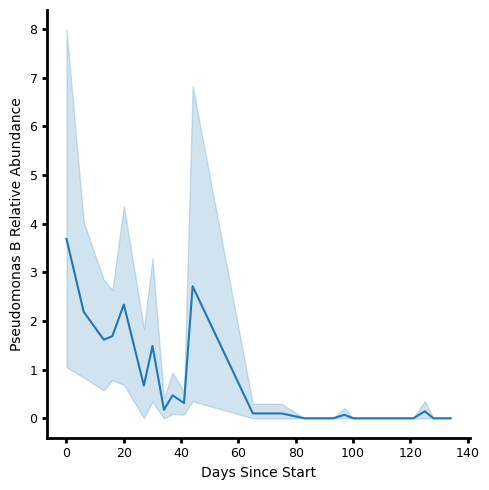

In [26]:
target_genus = "Pseudomonas_B_650453"
target_genus_plot_df = genus_sum_w_tp.loc[
    genus_sum_w_tp["Genus"] == target_genus, ["sampID", "AbundR100"]
]
target_genus_plot_df = target_genus_plot_df.merge(
    long_term_metadata[["sampID", "daysincestart"]],
    on="sampID",
    how="left",
).dropna(subset=["daysincestart"])

fig, ax = plt.subplots(figsize=(5, 5), dpi=100)
fig.patch.set_facecolor("white")
ax = sns.lineplot(
    data=target_genus_plot_df.sort_values("daysincestart"),
    x="daysincestart",
    y="AbundR100",
    errorbar=("ci", 95),
    color="#1f77b4",
)
plt.ylabel("Pseudomonas B Relative Abundance", fontsize=10)
plt.xlabel("Days Since Start", fontsize=10)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)

ax.spines["top"].set_color("black")
ax.spines["top"].set_linewidth(0)

ax.tick_params(axis="both", width=2)
plt.xticks(
    fontsize=9,
)
plt.yticks(fontsize=9)
plt.tight_layout()

In [27]:
correlation_df_filtered

,Column,Correlation_with_Summed_Defense_Z_Score
6,Curtobacterium_AbundR100,0.379709
21,Microbacterium_A_383321_AbundR100,0.300380
26,Pseudomonas_B_650453_AbundR100,0.299779
46,Rhizobium_C_501058_AbundR100,0.295323
23,Neorhizobium_500197_AbundR100,0.249880
...,...,...
98,Patulibacter_AbundR100,-0.166101
33,Variovorax_AbundR100,-0.167741
29,Rhodoferax_C_AbundR100,-0.188509
8,Flavobacterium_AbundR100,-0.208944


In [28]:
correlation_df_filtered.head(50)

,Column,Correlation_with_Summed_Defense_Z_Score
6,Curtobacterium_AbundR100,0.379709
21,Microbacterium_A_383321_AbundR100,0.300380
26,Pseudomonas_B_650453_AbundR100,0.299779
46,Rhizobium_C_501058_AbundR100,0.295323
23,Neorhizobium_500197_AbundR100,0.249880
9,Friedmanniella_AbundR100,0.242837
60,Buchnera_AbundR100,0.219857
2,Aeromicrobium_AbundR100,0.211997
4,Caulobacter_487784_AbundR100,0.196244
56,Duganella_570715_AbundR100,0.196149


In [29]:
plotting_df.rename(
    columns={
        "timepoint": "Timepoint",
        "Summed Defense Z Score": "Average Defense Z Score",
    }
).to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/For_talk/full_long_term_metadata.csv",
    index=False,
)

In [30]:
line_df[["timepoint", "Summed Defense Z Score"]].rename(
    columns={
        "timepoint": "Timepoint",
        "Summed Defense Z Score": "Average Defense Z Score, Averaged Across Samples in Timepoint",
    }
).to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/For_talk/timepoint_summed_defense_z_scores.csv",
    index=False,
)

In [31]:
line_df

,timepoint,Summed Defense Z Score,Curtobacterium_AbundR100,Microbacterium_A_383321_AbundR100,Pseudomonas_B_650453_AbundR100,Rhodoferax_C_AbundR100,Flavobacterium_AbundR100,Kordiimonas_AbundR100
0,t01,1.849502,0.500000,2.437500,3.687500,3.537500,5.325000,1.325000
1,t02,0.785208,1.025000,1.987500,2.187500,2.412500,1.725000,2.337500
2,t03,0.671566,0.342857,2.042857,1.614286,4.071429,4.557143,2.914286
3,t04,0.757626,0.475000,2.887500,1.687500,3.062500,1.925000,2.912500
4,t05,0.516350,0.337500,3.787500,2.337500,2.425000,0.175000,2.175000
5,t06,-0.038442,0.000000,1.700000,0.671429,3.442857,3.671429,3.828571
6,t07,0.288677,0.171429,1.414286,1.485714,3.028571,3.271429,2.842857
7,t08,-0.503596,0.112500,1.925000,0.175000,5.150000,6.512500,4.312500
8,t09,-0.110322,0.000000,1.600000,0.471429,4.442857,4.200000,3.942857
9,t10,-0.089784,0.162500,0.512500,0.312500,3.125000,12.637500,3.112500


In [32]:
abundance_df.rename(
    columns={
        "Series": "Genus",
        "Relative Abundance(Min-Max)": "Relative Abundance (Min-Max Normalized)",
    }
).to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/For_talk/top_and_bottom_3_taxa_abundance_corr.csv",
    index=False,
)

In [33]:
abundance_df

,timepoint,Series,Relative Abundance,Relative Abundance (Min-Max)
0,t01,Curtobacterium,0.500000,0.487805
1,t02,Curtobacterium,1.025000,1.000000
2,t03,Curtobacterium,0.342857,0.334495
3,t04,Curtobacterium,0.475000,0.463415
4,t05,Curtobacterium,0.337500,0.329268
...,...,...,...,...
163,t24,Kordiimonas,3.575000,0.596026
164,t25,Kordiimonas,5.100000,1.000000
165,t26,Kordiimonas,3.487500,0.572848
166,t27,Kordiimonas,3.112500,0.473510


Number of samples in histogram: 214


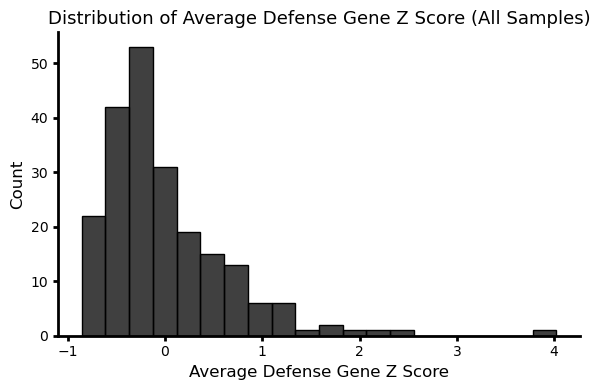

In [34]:
fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor("white")

hist_data = plotting_df["Summed Defense Z Score"].dropna()
sns.histplot(hist_data, bins=20, color="black", ax=ax)

plt.xlabel("Average Defense Gene Z Score", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Distribution of Average Defense Gene Z Score (All Samples)", fontsize=13)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2, labelsize=10)
plt.tight_layout()

print(f"Number of samples in histogram: {hist_data.shape[0]}")

In [35]:
rare_species_meta_data = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/rare_species_total_abund_generated.csv",
    index_col=0,
)
rare_species_meta_data

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,plate_row,plate_col,Total Reads,Experiment Type,Sample Month,daysincestart,Date and Time,has_rare_species,lacking_core_species,rare_species_total_abundR100
filename,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,A01,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2633048.0,112554.0,A,1,2248661.0,Long Term,November,0,2023-11-01 08:00:00,True,False,11.7
A2450525897_n01_LICRNA01_B01,B01,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5074184.0,226718.0,B,1,5984566.0,Long Term,November,0,2023-11-01 08:00:00,True,True,20.8
A2450525897_n01_LICRNA01_C01,C01,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2283008.0,97848.0,C,1,2936453.0,Long Term,November,0,2023-11-01 08:00:00,True,False,34.0
A2450525897_n01_LICRNA01_E01,E01,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,3004324.0,135512.0,E,1,2680737.0,Long Term,November,0,2023-11-01 08:00:00,True,True,5.3
A2450525897_n01_LICRNA01_F01,F01,LIC006,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,4577311.0,113185.0,F,1,2483101.0,Long Term,November,0,2023-11-01 08:00:00,True,True,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,D12,LIC542,plant,c1_t13,2/11/24,20:00,LICCIRC_02,LICRNA_05,4303811.0,383610.0,D,12,6510475.0,Circadian Experiment 1,February,102,2024-02-11 20:00:00,True,False,16.2
A2534491401_n01_LICRNA05_E12,E12,LIC495,plant,c1_t09,2/11/24,4:00,LICCIRC_02,LICRNA_05,4231836.0,451686.0,E,12,6178604.0,Circadian Experiment 1,February,102,2024-02-11 04:00:00,True,True,38.0
A2534491401_n01_LICRNA05_F12,F12,LIC421,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_05,4885375.0,360911.0,F,12,7035335.0,Circadian Experiment 1,February,101,2024-02-10 08:00:00,True,False,8.0


In [36]:
plotting_df_added_info = plotting_df.merge(
    right=rare_species_meta_data[["sampID", "rare_species_total_abundR100"]],
    on="sampID",
)

In [37]:
plotting_df_added_info

,sampID,timepoint,ham16s,Summed Defense Z Score,Experiment Type,Actinomycetospora_AbundR100,Actinoplanes_AbundR100,Aeromicrobium_AbundR100,Blastococcus_AbundR100,Caulobacter_487784_AbundR100,...,Croceibacterium_484881_AbundR100,Rhizorhabdus_AbundR100,Polaromonas_AbundR100,Jatrophihabitans_A_372606_AbundR100,UBA4416_AbundR100,Allorhizobium_500053_AbundR100,Herbiconiux_382278_AbundR100,Rank Within Timepoint,Zscore within Timepoint,rare_species_total_abundR100
0,LIC001,t01,0.242587,1.326926,Long Term,0.6,1.1,0.8,1.7,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.346435,11.7
1,LIC002,t01,0.367494,0.799594,Long Term,0.0,0.0,0.0,3.1,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,-0.915409,20.8
2,LIC003,t01,0.507472,2.305566,Long Term,0.0,0.0,4.9,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,-0.432376,34.0
3,LIC004,t01,0.554697,2.048900,Long Term,1.8,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,-0.269414,9.2
4,LIC005,t01,0.594141,0.560580,Long Term,0.6,0.0,0.6,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,-0.133303,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,LIC364,t08,0.082159,-0.681656,Long Term,0.5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,-0.536273,9.8
210,LIC365,t08,0.108041,-0.471329,Long Term,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.518322,1.7
211,LIC366,t08,0.103646,-0.704001,Long Term,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.339212,2.6
212,LIC367,t08,0.038971,-0.232981,Long Term,3.4,0.5,0.5,1.1,0.0,...,0.0,0.0,0.0,0.5,0.0,0.5,0.0,1.0,-2.296023,15.1


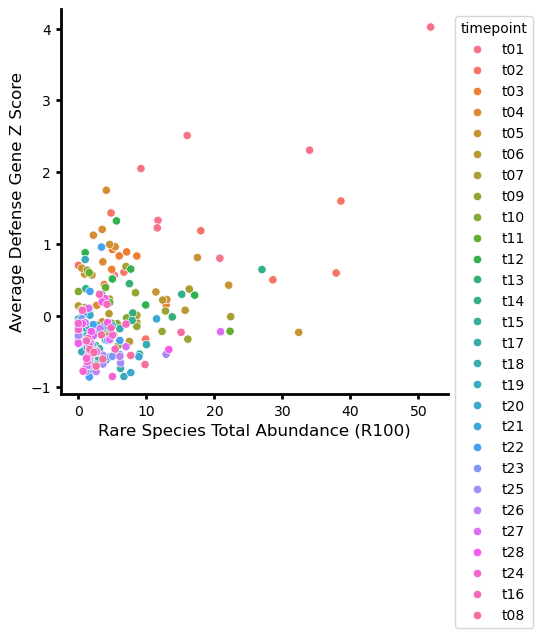

In [38]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
sns.scatterplot(
    data=plotting_df_added_info,
    x="rare_species_total_abundR100",
    y="Summed Defense Z Score",
    hue="timepoint",
    ax=ax,
)

plt.xlabel("Rare Species Total Abundance (R100)", fontsize=12)
plt.ylabel("Average Defense Gene Z Score", fontsize=12)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2, labelsize=10)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
# plt.tight_layout()

In [39]:
plotting_df_t14_onward = plotting_df.copy()
plotting_df_t14_onward["timepoint_number"] = (
    plotting_df_t14_onward["timepoint"].str.extract(r"(\d+)").astype(int)
)
plotting_df_t14_onward = plotting_df_t14_onward.loc[
    plotting_df_t14_onward["timepoint_number"] >= 14
]

minimum_present_samples = 7
abund_cols_t14_onward = [
    col for col in plotting_df_t14_onward.columns if col.endswith("_AbundR100")
]

correlation_results_t14_onward = []
for col in abund_cols_t14_onward:
    present_mask = plotting_df_t14_onward[col].fillna(0) > 0
    n_present_samples = int(present_mask.sum())

    if n_present_samples < minimum_present_samples:
        continue

    filtered_df = plotting_df_t14_onward.loc[
        present_mask, ["Summed Defense Z Score", col]
    ].dropna()

    correlation_results_t14_onward.append(
        {
            "Column": col,
            "Present_Sample_Count": n_present_samples,
            "Correlation_with_Summed_Defense_Z_Score": filtered_df[
                "Summed Defense Z Score"
            ].corr(filtered_df[col]),
        }
    )

correlation_df_t14_onward = pd.DataFrame(correlation_results_t14_onward).sort_values(
    "Correlation_with_Summed_Defense_Z_Score", ascending=False
)

correlation_df_t14_onward

,Column,Present_Sample_Count,Correlation_with_Summed_Defense_Z_Score
30,Paucimonas_AbundR100,33,0.318264
7,Frigoribacterium_AbundR100,100,0.305473
31,Rugamonas_570800_AbundR100,34,0.200538
36,Pigmentiphaga_AbundR100,23,0.168620
11,Kineococcus_AbundR100,68,0.165229
22,Pseudomonas_E_647464_AbundR100,112,0.161258
43,Pseudonocardia_AbundR100,12,0.159430
17,Microbacterium_A_383321_AbundR100,25,0.151350
15,Massilia_574544_AbundR100,115,0.141462
45,Caldora_AbundR100,30,0.130257


In [40]:
correlation_df

,Column,Correlation_with_Summed_Defense_Z_Score
63,Alsobacter_AbundR100,0.421464
6,Curtobacterium_AbundR100,0.379709
21,Microbacterium_A_383321_AbundR100,0.300380
26,Pseudomonas_B_650453_AbundR100,0.299779
46,Rhizobium_C_501058_AbundR100,0.295323
...,...,...
33,Variovorax_AbundR100,-0.167741
29,Rhodoferax_C_AbundR100,-0.188509
8,Flavobacterium_AbundR100,-0.208944
17,Kordiimonas_AbundR100,-0.455551


,Column,Correlation_with_Summed_Defense_Z_Score_All_Timepoints,Correlation_with_Summed_Defense_Z_Score_T14_Onward,Present_Sample_Count
0,Microbacterium_A_383321_AbundR100,0.300380,0.151350,25
1,Neorhizobium_500197_AbundR100,0.249880,-0.107477,116
2,Friedmanniella_AbundR100,0.242837,-0.068767,41
3,Aeromicrobium_AbundR100,0.211997,-0.154361,14
4,Duganella_570715_AbundR100,0.196149,-0.227709,15
5,Kineococcus_AbundR100,0.182614,0.165229,68
6,Janthinobacterium_571130_AbundR100,0.167907,-0.144573,19
7,Solirubrobacter_AbundR100,0.163604,0.106426,16
8,Marmoricola_A_392027_AbundR100,0.156649,0.039759,8
9,Blastococcus_AbundR100,0.142409,-0.106413,37


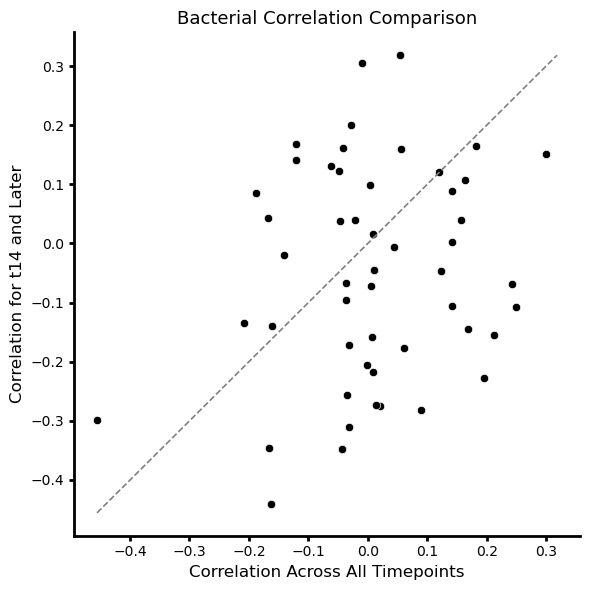

In [41]:
correlation_comparison_df = correlation_df[
    ["Column", "Correlation_with_Summed_Defense_Z_Score"]
].merge(
    correlation_df_t14_onward[
        [
            "Column",
            "Correlation_with_Summed_Defense_Z_Score",
            "Present_Sample_Count",
        ]
    ],
    on="Column",
    suffixes=("_All_Timepoints", "_T14_Onward"),
    how="inner",
)
correlation_comparison_df = correlation_comparison_df.dropna(
    subset=[
        "Correlation_with_Summed_Defense_Z_Score_All_Timepoints",
        "Correlation_with_Summed_Defense_Z_Score_T14_Onward",
    ]
)

if correlation_comparison_df.empty:
    print("No taxa overlap between the all-timepoint and t14+ correlation tables.")
else:
    fig, ax = plt.subplots(figsize=(6, 6))
    fig.patch.set_facecolor("white")
    sns.scatterplot(
        data=correlation_comparison_df,
        x="Correlation_with_Summed_Defense_Z_Score_All_Timepoints",
        y="Correlation_with_Summed_Defense_Z_Score_T14_Onward",
        color="black",
        ax=ax,
    )

    corr_bounds = correlation_comparison_df[
        [
            "Correlation_with_Summed_Defense_Z_Score_All_Timepoints",
            "Correlation_with_Summed_Defense_Z_Score_T14_Onward",
        ]
    ]
    min_corr = corr_bounds.min().min()
    max_corr = corr_bounds.max().max()
    ax.plot(
        [min_corr, max_corr],
        [min_corr, max_corr],
        linestyle="dashed",
        color="gray",
        linewidth=1.2,
    )

    plt.xlabel("Correlation Across All Timepoints", fontsize=12)
    plt.ylabel("Correlation for t14 and Later", fontsize=12)
    plt.title("Bacterial Correlation Comparison", fontsize=13)
    sns.despine()
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(2)
    ax.tick_params(axis="both", width=2, labelsize=10)
    plt.tight_layout()

correlation_comparison_df

In [42]:
correlation_comparison_df[
    [
        "Correlation_with_Summed_Defense_Z_Score_All_Timepoints",
        "Correlation_with_Summed_Defense_Z_Score_T14_Onward",
    ]
].corr()

,Correlation_with_Summed_Defense_Z_Score_All_Timepoints,Correlation_with_Summed_Defense_Z_Score_T14_Onward
Correlation_with_Summed_Defense_Z_Score_All_Timepoints,1.000000,0.187982
Correlation_with_Summed_Defense_Z_Score_T14_Onward,0.187982,1.000000


In [43]:
plotting_df_pre_t14 = plotting_df.copy()
plotting_df_pre_t14["timepoint_number"] = (
    plotting_df_pre_t14["timepoint"].str.extract(r"(\d+)").astype(int)
)
plotting_df_pre_t14 = plotting_df_pre_t14.loc[
    plotting_df_pre_t14["timepoint_number"] < 14
]

minimum_present_samples_pre_t14 = 7
abund_cols_pre_t14 = [
    col for col in plotting_df_pre_t14.columns if col.endswith("_AbundR100")
]

correlation_results_pre_t14 = []
for col in abund_cols_pre_t14:
    present_mask = plotting_df_pre_t14[col].fillna(0) > 0
    n_present_samples = int(present_mask.sum())

    if n_present_samples < minimum_present_samples_pre_t14:
        continue

    filtered_df = plotting_df_pre_t14.loc[
        present_mask, ["Summed Defense Z Score", col]
    ].dropna()

    correlation_results_pre_t14.append(
        {
            "Column": col,
            "Present_Sample_Count": n_present_samples,
            "Correlation_with_Summed_Defense_Z_Score": filtered_df[
                "Summed Defense Z Score"
            ].corr(filtered_df[col]),
        }
    )

correlation_df_pre_t14 = pd.DataFrame(correlation_results_pre_t14).sort_values(
    "Correlation_with_Summed_Defense_Z_Score", ascending=False
)

correlation_df_pre_t14

,Column,Present_Sample_Count,Correlation_with_Summed_Defense_Z_Score
53,Aureimonas_A_501548_AbundR100,7,0.621358
45,Brevundimonas_AbundR100,20,0.596424
2,Aeromicrobium_AbundR100,18,0.502568
34,Rhizobium_C_501058_AbundR100,11,0.488090
47,Agrobacterium_AbundR100,20,0.461221
26,Solirubrobacter_AbundR100,14,0.426129
37,Janthinobacterium_571130_AbundR100,32,0.252519
27,Sphingomonas_L_486704_AbundR100,97,0.247369
5,Curtobacterium_AbundR100,20,0.222085
41,Duganella_570715_AbundR100,27,0.215521


,Column,Correlation_with_Summed_Defense_Z_Score_All_Timepoints,Correlation_with_Summed_Defense_Z_Score_Pre_T14,Present_Sample_Count
0,Curtobacterium_AbundR100,0.379709,0.222085,20
1,Microbacterium_A_383321_AbundR100,0.300380,0.000250,59
2,Pseudomonas_B_650453_AbundR100,0.299779,0.072735,55
3,Rhizobium_C_501058_AbundR100,0.295323,0.488090,11
4,Neorhizobium_500197_AbundR100,0.249880,0.205451,93
5,Friedmanniella_AbundR100,0.242837,0.167066,54
6,Aeromicrobium_AbundR100,0.211997,0.502568,18
7,Duganella_570715_AbundR100,0.196149,0.215521,27
8,Pseudomonas_E_647626_AbundR100,0.182953,-0.138468,10
9,Kineococcus_AbundR100,0.182614,0.039659,76


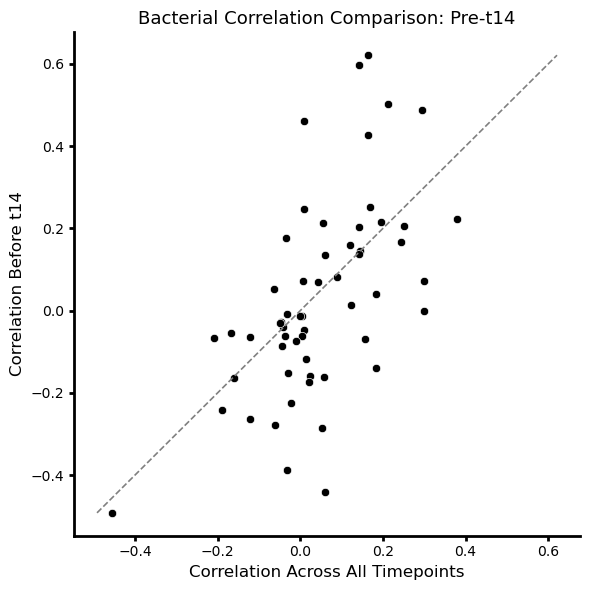

In [44]:
correlation_comparison_pre_t14_df = correlation_df[
    ["Column", "Correlation_with_Summed_Defense_Z_Score"]
].merge(
    correlation_df_pre_t14[
        [
            "Column",
            "Correlation_with_Summed_Defense_Z_Score",
            "Present_Sample_Count",
        ]
    ],
    on="Column",
    suffixes=("_All_Timepoints", "_Pre_T14"),
    how="inner",
)
correlation_comparison_pre_t14_df = correlation_comparison_pre_t14_df.dropna(
    subset=[
        "Correlation_with_Summed_Defense_Z_Score_All_Timepoints",
        "Correlation_with_Summed_Defense_Z_Score_Pre_T14",
    ]
)

if correlation_comparison_pre_t14_df.empty:
    print("No taxa overlap between the all-timepoint and pre-t14 correlation tables.")
else:
    fig, ax = plt.subplots(figsize=(6, 6))
    fig.patch.set_facecolor("white")
    sns.scatterplot(
        data=correlation_comparison_pre_t14_df,
        x="Correlation_with_Summed_Defense_Z_Score_All_Timepoints",
        y="Correlation_with_Summed_Defense_Z_Score_Pre_T14",
        color="black",
        ax=ax,
    )

    corr_bounds = correlation_comparison_pre_t14_df[
        [
            "Correlation_with_Summed_Defense_Z_Score_All_Timepoints",
            "Correlation_with_Summed_Defense_Z_Score_Pre_T14",
        ]
    ]
    min_corr = corr_bounds.min().min()
    max_corr = corr_bounds.max().max()
    ax.plot(
        [min_corr, max_corr],
        [min_corr, max_corr],
        linestyle="dashed",
        color="gray",
        linewidth=1.2,
    )

    plt.xlabel("Correlation Across All Timepoints", fontsize=12)
    plt.ylabel("Correlation Before t14", fontsize=12)
    plt.title("Bacterial Correlation Comparison: Pre-t14", fontsize=13)
    sns.despine()
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(2)
    ax.tick_params(axis="both", width=2, labelsize=10)
    plt.tight_layout()

correlation_comparison_pre_t14_df

In [45]:
correlation_comparison_pre_t14_df[
    [
        "Correlation_with_Summed_Defense_Z_Score_All_Timepoints",
        "Correlation_with_Summed_Defense_Z_Score_Pre_T14",
    ]
].corr()

,Correlation_with_Summed_Defense_Z_Score_All_Timepoints,Correlation_with_Summed_Defense_Z_Score_Pre_T14
Correlation_with_Summed_Defense_Z_Score_All_Timepoints,1.000000,0.586231
Correlation_with_Summed_Defense_Z_Score_Pre_T14,0.586231,1.000000


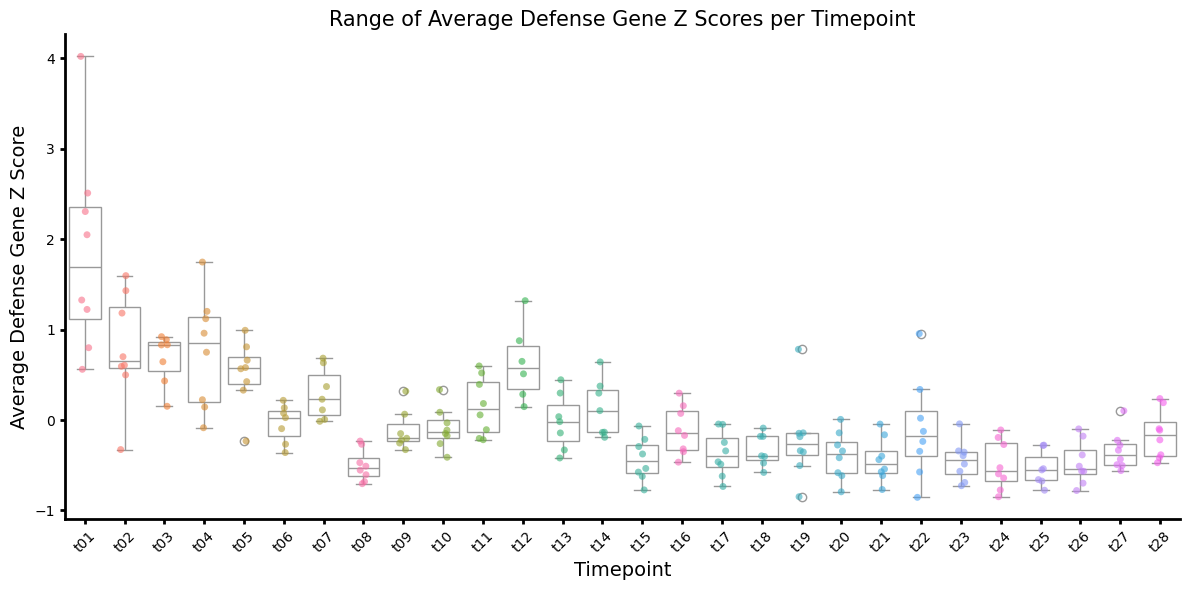

In [46]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("white")

sorted_timepoints = sorted(plotting_df["timepoint"].unique())

sns.boxplot(
    data=plotting_df,
    x="timepoint",
    y="Summed Defense Z Score",
    order=sorted_timepoints,
    ax=ax,
    color="white",
)

sns.stripplot(
    data=plotting_df,
    x="timepoint",
    y="Summed Defense Z Score",
    order=sorted_timepoints,
    alpha=0.6,
    ax=ax,
    hue="timepoint",
    legend=False,
)

plt.xlabel("Timepoint", fontsize=14)
plt.ylabel("Average Defense Gene Z Score", fontsize=14)
plt.title("Range of Average Defense Gene Z Scores per Timepoint", fontsize=15)

sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2, labelsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

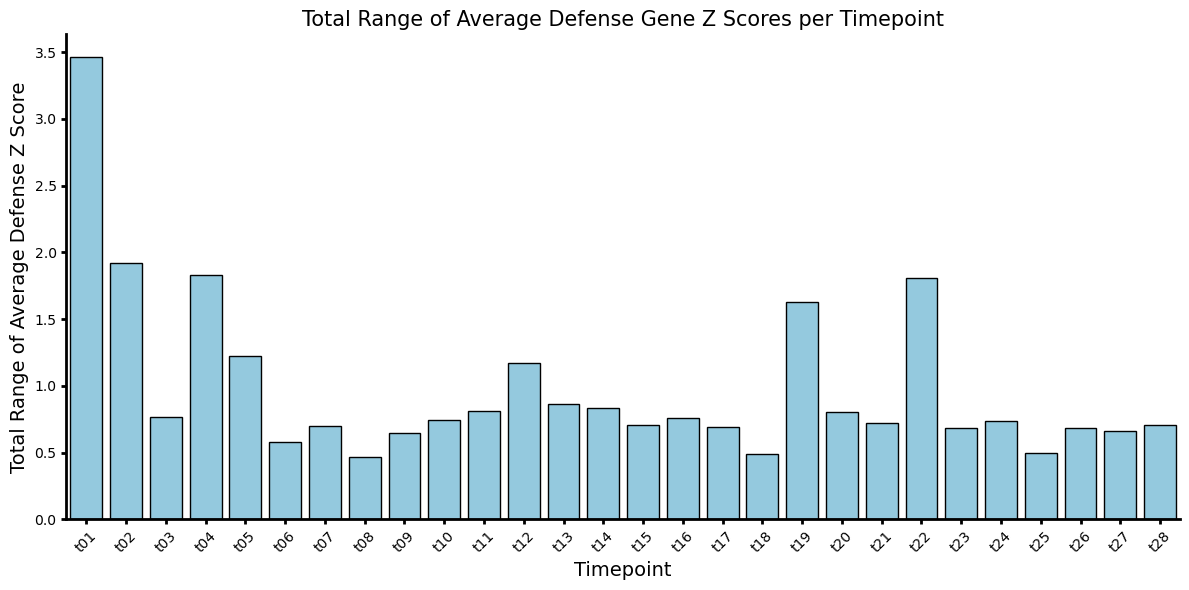

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the total range (max - min) within each timepoint
range_df = (
    plotting_df.groupby("timepoint")["Summed Defense Z Score"]
    .agg(lambda x: x.max() - x.min())
    .reset_index(name="Total Range")
)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("white")

sorted_timepoints = sorted(range_df["timepoint"].unique())

sns.barplot(
    data=range_df,
    x="timepoint",
    y="Total Range",
    order=sorted_timepoints,
    ax=ax,
    color="skyblue",
    edgecolor="black",
)

plt.xlabel("Timepoint", fontsize=14)
plt.ylabel("Total Range of Average Defense Z Score", fontsize=14)
plt.title("Total Range of Average Defense Gene Z Scores per Timepoint", fontsize=15)

sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2, labelsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()